In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import RELLISUR_DataLoader as rel
import srmodels as srm
import utils as u
from torch.cuda.amp import autocast, GradScaler

In [2]:
device = 'cuda'

In [3]:
batch_size = 1

train_ds, val_ds, test_ds = rel.get_SR_datasets(1,4)
train_dl, val_dl, test_dl = rel.get_SR_dataloaders(train_ds, val_ds, test_ds, batch_size)

In [4]:
model = srm.SimpleSR(scale_factor=4).to(device)
criterion = u.PSNRLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001) 
scaler = GradScaler()

/tmp/ipykernel_187436/3969652732.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [5]:
u.training_loop(model, criterion, optimizer, 10, train_dl, device, scaler)

/home/rfernandes/Documents/vc/SuperResLight/src/SR/utils.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [1/10], Loss: -0.056761
Epoch [2/10], Loss: -0.085727
Epoch [3/10], Loss: -0.087908
Epoch [4/10], Loss: -0.053411


KeyboardInterrupt: 

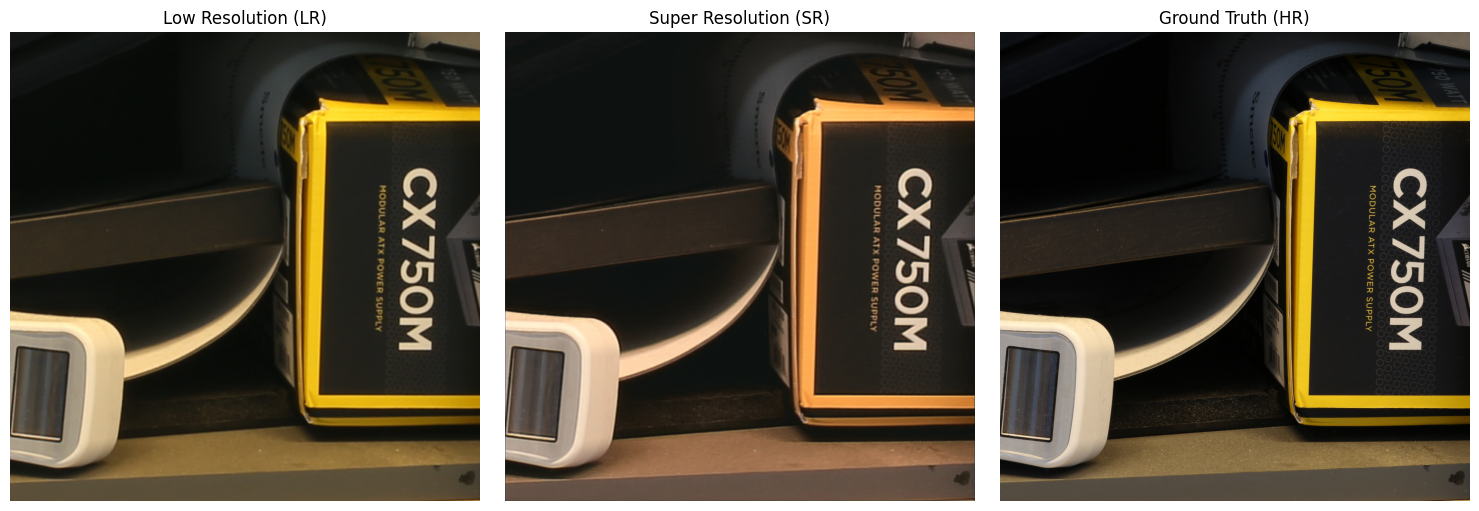

In [6]:
u.visualize_results(model, val_dl, device, num_samples=3)